# Handwritten Digit Recognition using CNN

Trained a CNN to look at an image of a handwritten digit (0–9) and correctly identify what number it is.

## Dataset — MNIST
- **70,000 images** of handwritten digits (0 to 9)
- Each image is **28×28 pixels**, grayscale
- Built into Keras — **no download needed!**


## Cell 1: Libraries Imported

In [2]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt

# Deep Learning
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

print(f'TensorFlow version: {tf.__version__}')
print('✅ Libraries imported!')

TensorFlow version: 2.20.0
✅ Libraries imported!


## Cell 2: MNIST Dataset
MNIST is built into Keras

In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Training images : {X_train.shape}')   # (60000, 28, 28)
print(f'Training labels : {y_train.shape}')   # (60000,)
print(f'Test images     : {X_test.shape}')    # (10000, 28, 28)
print(f'Test labels     : {y_test.shape}')    # (10000,)
print(f'\nClasses: {np.unique(y_train)}')      # 0 to 9

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images : (60000, 28, 28)
Training labels : (60000,)
Test images     : (10000, 28, 28)
Test labels     : (10000,)

Classes: [0 1 2 3 4 5 6 7 8 9]


## Cell 3: Visualize Sample Images

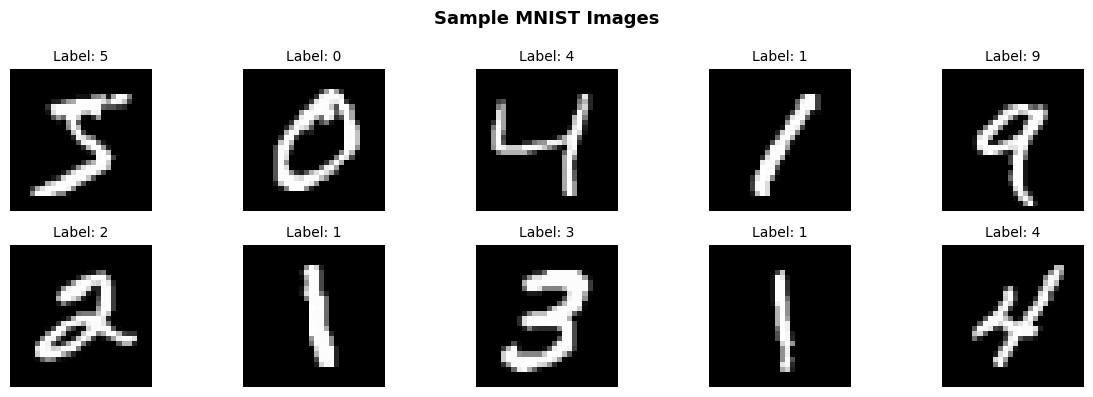


Pixel value range: 0 to 255


In [4]:
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}', fontsize=10)
    plt.axis('off')

plt.suptitle('Sample MNIST Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Each image is 28x28 pixels, values between 0 (black) and 255 (white)
print(f'\nPixel value range: {X_train.min()} to {X_train.max()}')

## Cell 4: Preprocess the Data

Three things to do:
1. **Reshape** — add channel dimension (CNN expects 4D input)
2. **Normalize** — scale pixel values from 0–255 to 0–1 (helps training)
3. **One-hot encode** — convert labels like `3` → `[0,0,0,1,0,0,0,0,0,0]`

In [5]:
# 1. Reshape: (60000, 28, 28) → (60000, 28, 28, 1)  [1 = grayscale channel]
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# 2. Normalize pixel values to 0–1
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# 3. One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f'X_train shape : {X_train.shape}')         # (60000, 28, 28, 1)
print(f'y_train shape : {y_train_cat.shape}')     # (60000, 10)
print(f'\nExample label before: {y_train[0]}')
print(f'Example label after : {y_train_cat[0]}')
print('✅ Preprocessing done!')

X_train shape : (60000, 28, 28, 1)
y_train shape : (60000, 10)

Example label before: 5
Example label after : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
✅ Preprocessing done!


## Cell 5: CNN Model

We use a simple Sequential model — layers stacked one after another.

In [6]:
model = Sequential([

    # --- Block 1: First Convolution ---
    # 32 filters of size 3x3, detect basic edges and curves
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    # Reduce spatial size by taking max in 2x2 windows
    MaxPooling2D(pool_size=(2,2)),

    # --- Block 2: Second Convolution ---
    # 64 filters to detect more complex patterns
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # --- Flatten & Classify ---
    Flatten(),                          # Convert 2D → 1D
    Dense(128, activation='relu'),      # Fully connected layer
    Dropout(0.3),                       # Drop 30% neurons to prevent overfitting
    Dense(10, activation='softmax')     # 10 outputs (one per digit)
])

# Compile the model
model.compile(
    optimizer='adam',                        # Adam = smart learning rate adjustment
    loss='categorical_crossentropy',         # Standard loss for multi-class classification
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 6: Train the Model

In [7]:
# Train for 10 epochs — each epoch = model sees all 60,000 images once
history = model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=128,               # Process 128 images at a time
    validation_split=0.1,
    verbose=1
)

print('\n✅ Training complete!')

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.9192 - loss: 0.2597 - val_accuracy: 0.9850 - val_loss: 0.0590
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.9771 - loss: 0.0760 - val_accuracy: 0.9870 - val_loss: 0.0456
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9835 - loss: 0.0550 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9859 - loss: 0.0454 - val_accuracy: 0.9893 - val_loss: 0.0402
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9878 - loss: 0.0378 - val_accuracy: 0.9902 - val_loss: 0.0370
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9902 - loss: 0.0320 - val_accuracy: 0.9915 - val_loss: 0.0321
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9917 - loss: 0.0265 - val_accuracy: 0.9907 - val_loss: 0.0376
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 97ms/step - accuracy: 0.9923 - loss: 0.0225 - 

## Cell 8: Plot Training History
Visualize how accuracy and loss changed over epochs.

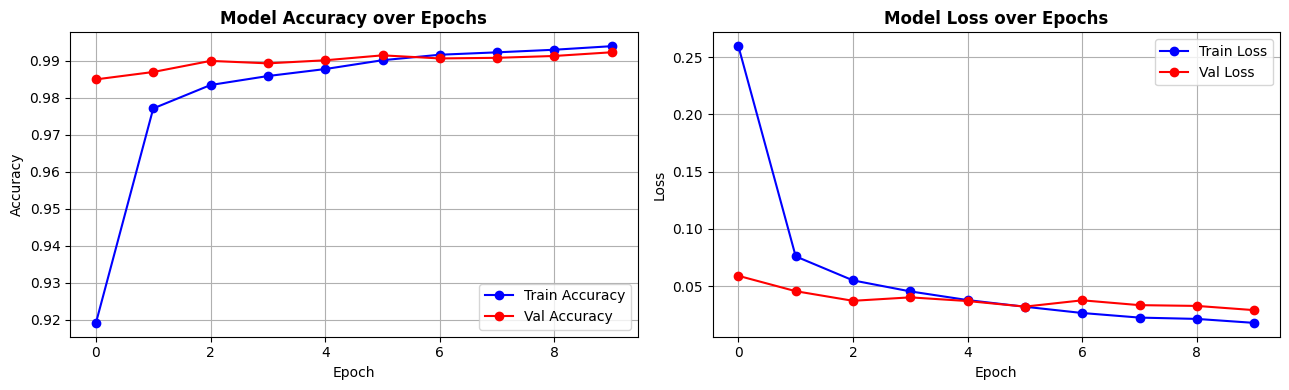

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='blue', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='red',  marker='o')
ax1.set_title('Model Accuracy over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss', color='blue', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss',   color='red',  marker='o')
ax2.set_title('Model Loss over Epochs', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

# ✅ Good sign: train and val curves close together = no overfitting!

## Cell 8: Evaluate on Test Set

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print('=' * 35)
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 35)

  Test Accuracy : 99.08%
  Test Loss     : 0.0252


## Cell 9: Visualize Predictions
 Model predicts vs the actual labels.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


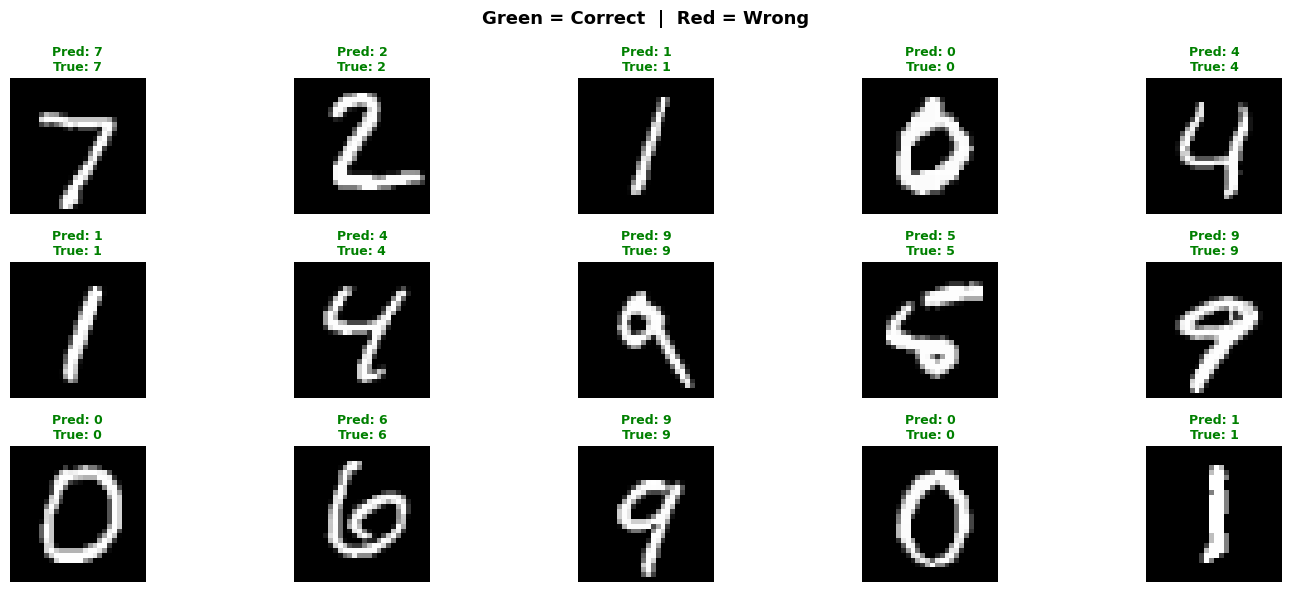

In [10]:
# Get predictions on test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)   # Pick digit with highest probability

# Plot 15 test images with predictions
plt.figure(figsize=(15, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    predicted = y_pred[i]
    actual    = y_test[i]
    color     = 'green' if predicted == actual else 'red'

    plt.title(f'Pred: {predicted}\nTrue: {actual}',
              color=color, fontsize=9, fontweight='bold')
    plt.axis('off')

plt.suptitle('Green = Correct  |  Red = Wrong', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 10:Where the Model Goes Wrong

1.   List item
2.   List item



Total wrong predictions: 92 out of 10000


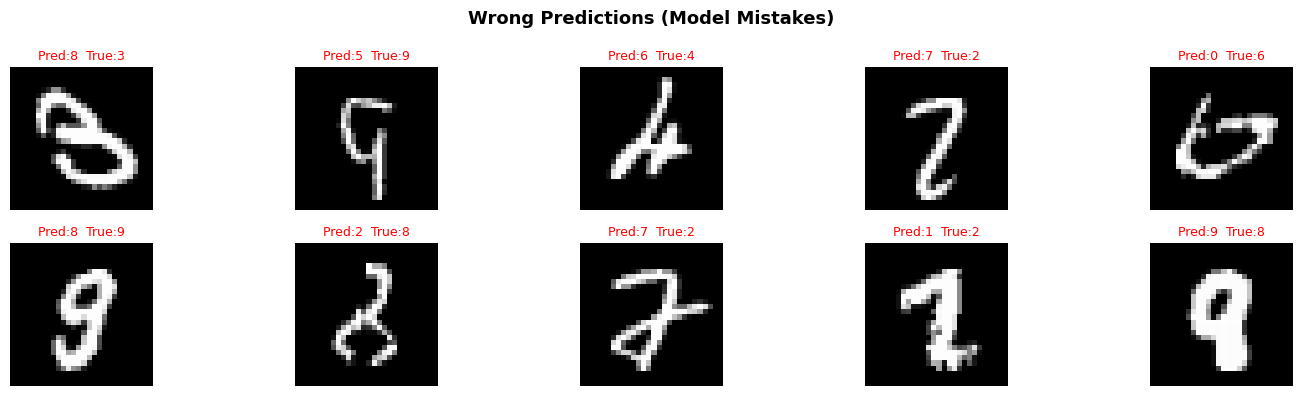

In [11]:
# Find wrongly predicted images
wrong_indices = np.where(y_pred != y_test)[0]
print(f'Total wrong predictions: {len(wrong_indices)} out of {len(y_test)}')

# Show first 10 mistakes
plt.figure(figsize=(15, 4))
for i, idx in enumerate(wrong_indices[:10]):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f'Pred:{y_pred[idx]}  True:{y_test[idx]}',
              color='red', fontsize=9)
    plt.axis('off')

plt.suptitle('Wrong Predictions (Model Mistakes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
# These are genuinely hard-to-read handwriting samples!



```
# This is formatted as code
```

## Cell 11: Model Saved

In [12]:
model.save('digit_recognizer_cnn.h5')
print('✅ Model saved as digit_recognizer_cnn.h5')

# Download to your computer
from google.colab import files
files.download('digit_recognizer_cnn.h5')

✅ Model saved as digit_recognizer_cnn.h5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>